# NEOFC - Prepare physio data for YRSP dataset

In [1]:
from pathlib import Path 
import pandas as pd 
import numpy as np 

import neurokit2 as nk
from scipy.signal import welch

# working directory
wd = Path.cwd() 
print(wd)

/Users/llotter/projects/mapfc


## Load data

### Load subjects

In [2]:
subs_all = (
    pd.read_pickle(wd / "data_deriv" / "connectomes" / "yrsp" / "parc-Schaefer200_connectivity.pkl.gz")
    .coords["sub"].values
)
subs_all = sorted(set(subs_all))

### Load data

In [3]:
# raw data per run
data_yrsp_pupil = {}
for sub in subs_all:
    data_yrsp_pupil[sub] = pd.DataFrame(
        np.vstack([
            np.loadtxt(
                wd / "data_source" / "pheno" / "yrsp" / "eye_tracking" / sub / f"{sub}_task-rest_run-0{run}_et.tsv", 
                dtype=np.float32,
                delimiter="\t",
            )
            for run in [1, 2]
        ]),
        columns=pd.Index(np.arange(400), name="tp"),
        index=[1, 2],
    )
data_yrsp_pupil = pd.concat(data_yrsp_pupil, axis=0, names=["sub", "run"])
display(data_yrsp_pupil.head())
data_yrsp_pupil.to_csv(wd / "data_deriv" / "pheno" / "yrsp" / "pupil_size.csv")


tp                      0            1            2            3    \
sub        run                                                       
sub-pa1372 1    3770.365234  3242.272949  3505.371338  3274.152588   
           2    3086.111328  3245.848877  3200.286865  3221.629395   
sub-pa1387 1    4580.771484  4420.592285  4274.661133  4339.881836   
           2    5216.769043  5086.520020  4819.820312  4844.306641   
sub-pa1416 1    2565.416992  2602.452393  2619.939941  2367.368164   

tp                      4            5            6            7    \
sub        run                                                       
sub-pa1372 1    3241.026855  3301.324707  3559.668701  3709.558105   
           2    3164.400146  3471.177002  3449.013428  2760.857422   
sub-pa1387 1    4584.986816  4289.473633  3671.341309  3101.029541   
           2    4615.361328  4482.888184  4594.196289  4652.426270   
sub-pa1416 1    2467.317383  2704.221436  2902.087891  2928.224854   

tp                      8            9    ...          390          391  \
sub        run                            ...                             
sub-pa1372 1    3758.690918  3780.346436  ...  3144.728271  2993.083984   
           2    2270.319580  2454.246094  ...  3874.798096  3449.990234   
sub-pa1387 1    3213.840332  3889.824219  ...     0.000090     0.000004   
           2    4395.626465  4173.775879  ...  4853.252930  4173.286621   
sub-pa1416 1    2315.579346  2143.100586  ...  2927.723877  2306.992920   

tp                       392           393           394           395  \
sub        run                                                           
sub-pa1372 1    2.757317e+03  2.619388e+03  2.492914e+03  2.032639e+03   
           2    2.840060e+03  2.999391e+03  3.098803e+03  3.034826e+03   
sub-pa1387 1    1.680616e-07  7.262564e-09  3.138422e-10  1.356228e-11   
           2    3.055062e+03  2.668850e+03  2.301500e+03  2.058788e+03   
sub-pa1416 1    1.444961e+03  1.712800e+03  2.046860e+03  2.098696e+03   

tp                       396           397           398           399  
sub        run                                                          
sub-pa1372 1    1.824285e+03  1.973178e+03  1.965503e+03  2.028358e+03  
           2    3.305174e+03  3.275688e+03  3.580898e+03  3.917870e+03  
sub-pa1387 1    5.860763e-13  2.532653e-14  1.094540e-15  4.930730e-17  
           2    1.946611e+03  1.598797e+03  6.877056e+02  2.749645e+02  
sub-pa1416 1    1.983331e+03  1.955599e+03  1.723635e+03  1.535303e+03  

[5 rows x 400 columns]

## Process data

### Data cleaning function

In [4]:
def clean_pupil(ts, fs=1.0, low_cut=None, high_cut=None, amp_bounds=(300, 10000), max_gap=5):
    """Return cleaned pupil trace (NaN for unusable), plus QC dict."""
    ts = ts.copy().astype(float)
    
    # 0) amplitude filter
    ts[(ts < amp_bounds[0]) | (ts > amp_bounds[1])] = np.nan
    
    # 1) convert to mm
    ts = np.sqrt(ts)
    
    # 2) velocity filter
    v = np.abs(np.diff(ts, prepend=np.nan))
    thr = np.nanmedian(v) + 5 * (1.4826 * np.nanmedian(np.abs(v - np.nanmedian(v))))
    ts[v > thr] = np.nan
    
    # 3) interpolate short gaps
    s = pd.Series(ts)
    is_bad = s.isna()
    gap_id = (is_bad != is_bad.shift()).cumsum()
    gap_len = is_bad.groupby(gap_id).transform('sum')
    ts[(gap_len > max_gap) & is_bad] = np.nan  # mark long gaps again
    ts = pd.Series(ts).interpolate(limit=max_gap, limit_direction='both').to_numpy()
    
    # mark long gaps permanently
    ts[(gap_len > max_gap) & is_bad] = np.nan
    
    # 4) band-pass filtering with NeuroKit-2: will not use currently
    if not (low_cut is None and high_cut is None):
        ts_filt = nk.signal_filter(
            ts,
            sampling_rate=fs,
            lowcut=low_cut,
            highcut=high_cut,
            order=2,                 
            method="butterworth"
        )
    else:
        ts_filt = ts

    # QC
    qc = dict(
        prop_good=np.mean(~np.isnan(ts_filt)),
        max_gap=np.nanmax(gap_len*is_bad),
        mad_vel=1.4826*np.nanmedian(np.abs(v - np.nanmedian(v)))
    )
    return ts_filt, qc

### Data extraction functions

In [5]:
def pupil_unrest_index(ts_filt):
    """Pupil Unrest Index (PUI): RMS of sample-to-sample differences.

    """
    # prepend NaN so the first element is excluded from the mean (no valid predecessor)
    diff = np.diff(ts_filt, prepend=np.nan)
    return np.sqrt(np.nanmean(diff**2))


def lf_power(ts_filt, band, fs=1.0, nperseg=256):
    """Band power in a specified frequency range using Welch's PSD method.

    Uses longest contiguous non-NaN segment to avoid artifacts from concatenating samples across gaps.
    """
    # identify contiguous non-NaN segments
    is_valid = ~np.isnan(ts_filt)
    segments = []
    start = None
    for i, v in enumerate(is_valid):
        if v and start is None:
            start = i
        elif not v and start is not None:
            segments.append(ts_filt[start:i])
            start = None
    if start is not None:
        segments.append(ts_filt[start:])

    if not segments:
        return np.nan

    # use the longest segment to maximise frequency resolution
    data = max(segments, key=len)

    if len(data) < nperseg:
        return np.nan

    f, Pxx = welch(data, fs=fs, nperseg=nperseg, detrend='constant', window='hann')

    # integrate PSD over band: multiply by frequency resolution for proper power in signal² units
    df = f[1] - f[0]
    idx = (f >= band[0]) & (f <= band[1])
    return Pxx[idx].sum() * df

### Clean pupil data

In [6]:
# cleaned data
data_yrsp_pupil_proc_full = data_yrsp_pupil.copy(deep=True)
data_yrsp_pupil_proc_low = data_yrsp_pupil.copy(deep=True)
data_yrsp_pupil_proc_qc = {}
for idx in data_yrsp_pupil_proc_full.index:
    
    # process
    ts = data_yrsp_pupil.loc[idx]
    ts_clean_full, qc = clean_pupil(ts)
    
    # store
    data_yrsp_pupil_proc_full.loc[idx] = ts_clean_full.astype(np.float32)
    data_yrsp_pupil_proc_qc[idx] = qc
    
# save timeseries
data_yrsp_pupil_proc_full.to_csv(wd / "data_deriv" / "pheno" / "yrsp" / "pupil_size_proc_full.csv")
print("Pupil size processed, no bandpass filter")
display(data_yrsp_pupil_proc_full.head())

# sort and save quality
data_yrsp_pupil_proc_qc = pd.DataFrame(data_yrsp_pupil_proc_qc).T
data_yrsp_pupil_proc_qc.index.names = ["sub", "run"]
data_yrsp_pupil_proc_qc.to_csv(wd / "data_deriv" / "pheno" / "yrsp" / "pupil_size_proc_qc.csv")
data_yrsp_pupil_proc_qc

Pupil size processed, no bandpass filter


tp                    0          1          2          3          4    \
sub        run                                                          
sub-pa1372 1    61.403301  56.940960  59.206177  57.220211  56.930016   
           2    55.552780  56.972351  56.571079  56.759399  56.253002   
sub-pa1387 1    67.681396  66.487534  65.380890  65.877777  67.712532   
           2    72.227203  71.319839  69.424927  69.601051  67.936447   
sub-pa1416 1    50.649944  51.014236  51.185349  48.655609  49.672100   

tp                    5          6          7          8          9    ...  \
sub        run                                                         ...   
sub-pa1372 1    57.457157  59.662960  60.906143  61.308163  61.484524  ...   
           2    58.916695  58.728302  52.543861  47.647869  49.540348  ...   
sub-pa1387 1    65.494072  60.591595  55.686890  56.690742  62.368454  ...   
           2    66.954376  67.780502  68.208694  66.299522  64.604767  ...   
sub-pa1416 1    52.002129  53.871029  54.113075  48.120468  46.293633  ...   

tp                    390        391        392        393        394  \
sub        run                                                          
sub-pa1372 1    56.077877  54.709084  52.510166  51.179962  49.929089   
           2    62.247875  58.736618  53.292213  54.766697  55.666893   
sub-pa1387 1          NaN        NaN        NaN        NaN        NaN   
           2    69.665291  64.600983  58.130947  51.660915  47.973953   
sub-pa1416 1    54.108444  48.031166  44.708576  41.385986  45.242237   

tp                    395        396        397        398        399  
sub        run                                                         
sub-pa1372 1    45.084801  42.711651  44.420471  44.334000  45.037296  
           2    55.089252  57.490646  57.233624  59.840603  62.592888  
sub-pa1387 1          NaN        NaN        NaN        NaN        NaN  
           2    45.373871  44.120411  39.984955  39.984955  39.984955  
sub-pa1416 1    45.811523  44.534603  44.222149  41.516682  39.182945  

[5 rows x 400 columns]

prop_good  max_gap   mad_vel
sub        run                              
sub-pa1372 1       1.0000      1.0  1.337988
           2       1.0000      0.0  1.295745
sub-pa1387 1       0.7100     38.0  2.743471
           2       1.0000      3.0  1.387382
sub-pa1416 1       1.0000      1.0  1.276937
           2       1.0000      2.0  1.024132
sub-pa1560 1       0.0300    123.0  9.422288
           2       0.5750     53.0  2.373778
sub-pa1582 1       1.0000      2.0  1.871037
           2       1.0000      0.0  2.159308
sub-pa1604 1       1.0000      1.0  1.065634
           2       1.0000      3.0  1.085694
sub-pa1674 1       1.0000      4.0  2.489432
           2       0.9825      7.0  3.192031
sub-pa1700 1       1.0000      2.0  1.717271
           2       1.0000      2.0  1.494074
sub-pa1766 1       0.9450      8.0  3.526719
           2       1.0000      1.0  1.457190
sub-pa1792 1       1.0000      2.0  1.470933
           2       1.0000      1.0  1.010612
sub-pa1811 1       1.0000      2.0  1.945606
           2       1.0000      3.0  1.062608
sub-pa1834 1       1.0000      1.0  1.111617
           2       1.0000      2.0  1.073979
sub-pa1841 1       0.8975     19.0  3.563617
           2       0.9825      7.0  4.107304
sub-pa1859 1       1.0000      0.0  2.221014
           2       1.0000      2.0  1.408492
sub-pa1913 1       1.0000      1.0  2.204702
           2       0.9225     10.0  3.760702
sub-pa1940 1       0.9125     11.0  2.402556
           2       1.0000      2.0  1.248674
sub-pa1978 1       1.0000      4.0  1.651619
           2       1.0000      3.0  1.174511
sub-pa2079 1       1.0000      1.0  2.053344
           2       1.0000      1.0  1.754196
sub-pa2100 1       1.0000      3.0  1.277622
           2       1.0000      4.0  0.505003
sub-pa2106 1       1.0000      0.0  0.784827
           2       1.0000      2.0  1.579681
sub-pa2196 1       1.0000      2.0  1.542601
           2       1.0000      0.0  1.531583
sub-pa2213 1       1.0000      2.0  1.874389
           2       1.0000      4.0  2.528778
sub-pa2216 1       1.0000      2.0  2.975812
           2       0.9750     10.0  1.016594
sub-pa2220 1       1.0000      0.0  1.174590
           2       1.0000      0.0  1.170060
sub-pa2221 1       1.0000      3.0  1.809102
           2       1.0000      3.0  1.694912
sub-pa2226 1       1.0000      1.0  1.466993
           2       1.0000      2.0  1.332856

### Prepare data for analysis


In [7]:
threshold = 0.8

# cleaned data
df_physio = data_yrsp_pupil_proc_qc.copy(deep=True)
for idx in df_physio.index:
    # get timeseries
    ts_full = data_yrsp_pupil_proc_full.loc[idx]
    
    # flag qc
    df_physio.loc[idx, "qc"] = df_physio.loc[idx, "prop_good"] >= threshold 
    # calculate pupil unrest index
    df_physio.loc[idx, "pui"] = pupil_unrest_index(ts_full)
    # calculate power in three bands
    df_physio.loc[idx, "lf_s"] = lf_power(ts_full, band=(0.04, 0.1))
    df_physio.loc[idx, "lf_r"] = lf_power(ts_full, band=(0.1, 0.24))
    df_physio.loc[idx, "hf_p"] = lf_power(ts_full, band=(0.25, 0.5))
    
# save
df_physio.to_csv(wd / "data_deriv" / "pheno" / "yrsp" / "pupil_size_proc_pui.csv")
display(df_physio.head(50))

prop_good  max_gap   mad_vel     qc        pui       lf_s  \
sub        run                                                              
sub-pa1372 1       1.0000      1.0  1.337988   True   2.393952   4.781189   
           2       1.0000      0.0  1.295745   True   2.347219   4.625817   
sub-pa1387 1       0.7100     38.0  2.743471  False   4.991361        NaN   
           2       1.0000      3.0  1.387382   True   3.165966  16.650440   
sub-pa1416 1       1.0000      1.0  1.276937   True   2.385295   8.296893   
           2       1.0000      2.0  1.024132   True   1.761823   4.532355   
sub-pa1560 1       0.0300    123.0  9.422288  False  28.619255        NaN   
           2       0.5750     53.0  2.373778  False   3.705057        NaN   
sub-pa1582 1       1.0000      2.0  1.871037   True   3.243751   3.632503   
           2       1.0000      0.0  2.159308   True   3.664200   9.602277   
sub-pa1604 1       1.0000      1.0  1.065634   True   1.769337   2.672965   
           2       1.0000      3.0  1.085694   True   1.881381   3.198010   
sub-pa1674 1       1.0000      4.0  2.489432   True   5.486865  11.991272   
           2       0.9825      7.0  3.192031   True   6.069412  18.065208   
sub-pa1700 1       1.0000      2.0  1.717271   True   3.266023   9.567749   
           2       1.0000      2.0  1.494074   True   2.837815   5.528803   
sub-pa1766 1       0.9450      8.0  3.526719   True   6.526982  23.502905   
           2       1.0000      1.0  1.457190   True   2.711312  17.706856   
sub-pa1792 1       1.0000      2.0  1.470933   True   3.055419   4.082307   
           2       1.0000      1.0  1.010612   True   1.794400   1.546948   
sub-pa1811 1       1.0000      2.0  1.945606   True   3.227790  13.469702   
           2       1.0000      3.0  1.062608   True   2.256513   2.526373   
sub-pa1834 1       1.0000      1.0  1.111617   True   2.016390   5.716503   
           2       1.0000      2.0  1.073979   True   2.110138   6.080162   
sub-pa1841 1       0.8975     19.0  3.563617   True   6.738245        NaN   
           2       0.9825      7.0  4.107304   True   7.199740        NaN   
sub-pa1859 1       1.0000      0.0  2.221014   True   4.027521  27.024385   
           2       1.0000      2.0  1.408492   True   2.864786   6.889049   
sub-pa1913 1       1.0000      1.0  2.204702   True   4.303154  30.736322   
           2       0.9225     10.0  3.760702   True   5.949538  57.237587   
sub-pa1940 1       0.9125     11.0  2.402556   True   4.921445  20.897221   
           2       1.0000      2.0  1.248674   True   2.237997   7.275033   
sub-pa1978 1       1.0000      4.0  1.651619   True   3.687199  20.222494   
           2       1.0000      3.0  1.174511   True   2.584518  11.230048   
sub-pa2079 1       1.0000      1.0  2.053344   True   3.559300  12.471821   
           2       1.0000      1.0  1.754196   True   3.077624  13.213583   
sub-pa2100 1       1.0000      3.0  1.277622   True   2.284176   4.588652   
           2       1.0000      4.0  0.505003   True   1.205877   0.854905   
sub-pa2106 1       1.0000      0.0  0.784827   True   1.364112   1.868326   
           2       1.0000      2.0  1.579681   True   2.972811  16.811319   
sub-pa2196 1       1.0000      2.0  1.542601   True   2.611240   4.595389   
           2       1.0000      0.0  1.531583   True   2.559043   5.038767   
sub-pa2213 1       1.0000      2.0  1.874389   True   4.098853  22.048471   
           2       1.0000      4.0  2.528778   True   4.896375  33.953392   
sub-pa2216 1       1.0000      2.0  2.975812   True   6.098484  30.858522   
           2       0.9750     10.0  1.016594   True   2.374619   1.987005   
sub-pa2220 1       1.0000      0.0  1.174590   True   2.150639   3.348202   
           2       1.0000      0.0  1.170060   True   1.983725   1.995870   
sub-pa2221 1       1.0000      3.0  1.809102   True   4.058475  11.223841   
           2       1.0000      3.0  1.694912   True   3.341424  22.064230   

           

## Plot

### Plot all timeseries

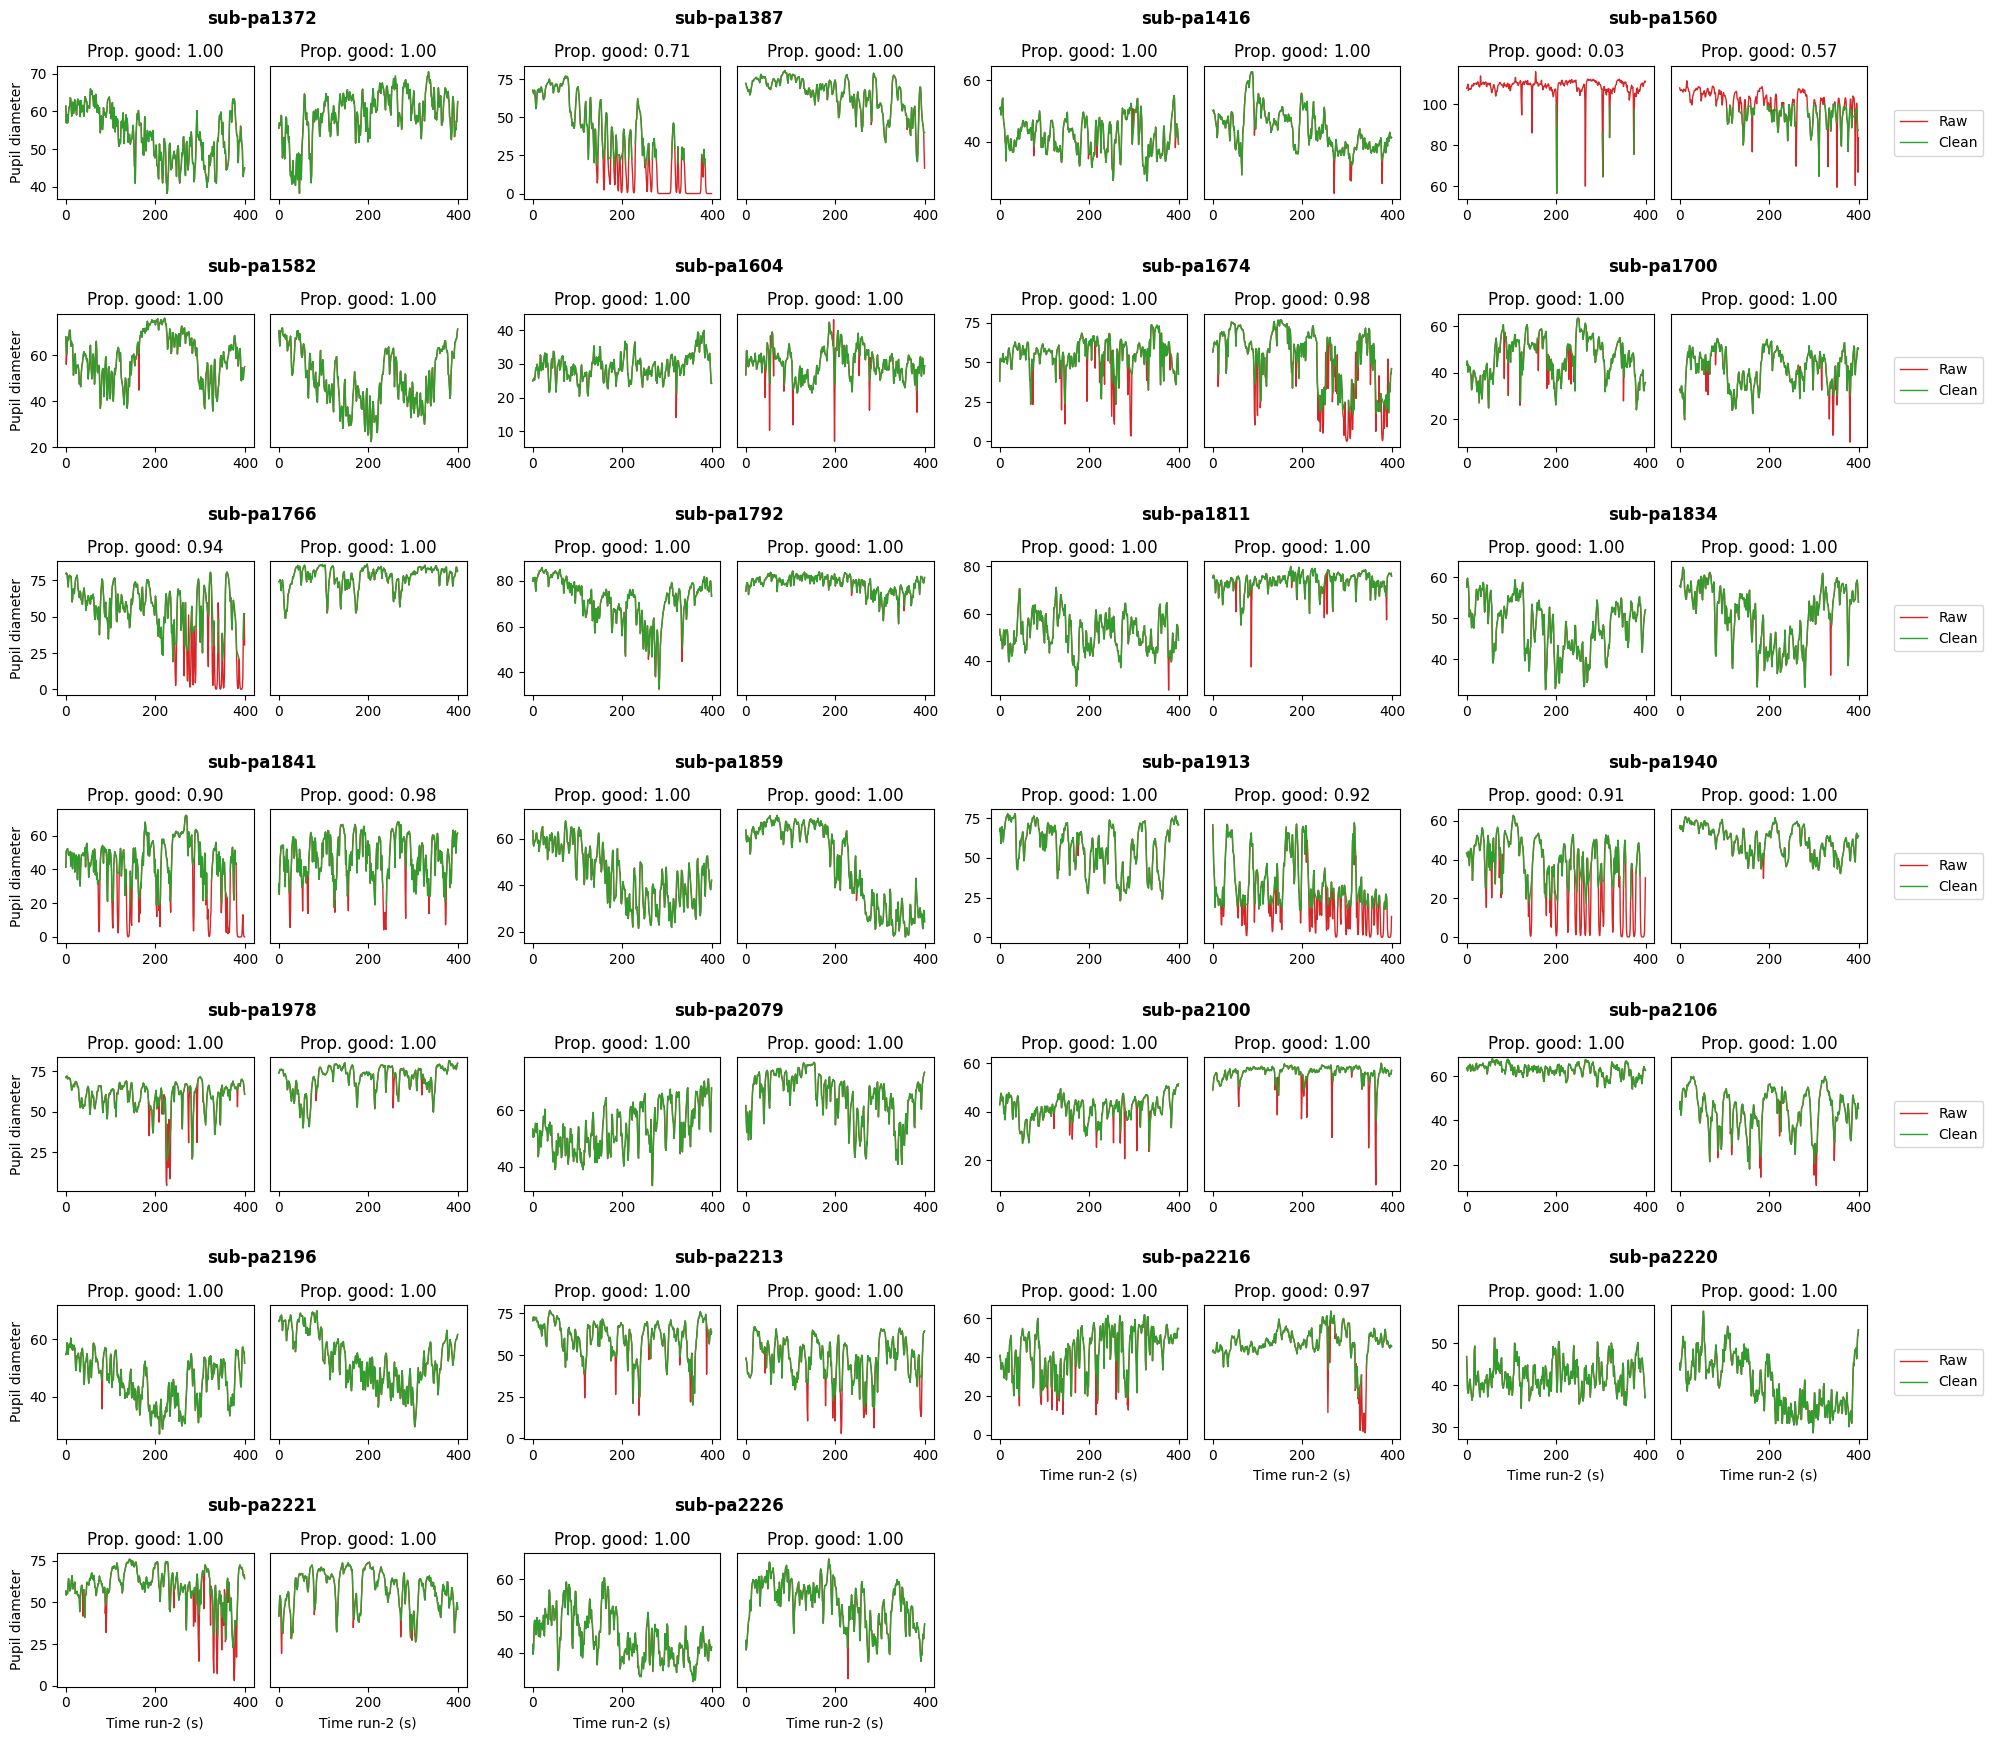

In [8]:

# plot
import matplotlib.pyplot as plt
n_cols = 4
n_rows = (len(subs_all) // n_cols) + 1
fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*2.5), sharex=True, sharey=False)
for sub, ax_main in zip(data_yrsp_pupil.index.get_level_values("sub").unique(), axes.ravel()):
    
    # layout
    ax_main.set_title(sub, weight="bold", pad=30)
    ax_main.set_axis_off()
    
    # runs
    ax1 = ax_main.inset_axes([0, 0, 0.48, 1])
    ax2 = ax_main.inset_axes([0.52, 0, 0.48, 1])
    for run, ax in enumerate([ax1, ax2], start=1):
        ax.plot(data_yrsp_pupil.loc[(sub, run), :].transform("sqrt"), lw=1, alpha=1, c="tab:red", label="Raw")
        ax.plot(data_yrsp_pupil_proc_full.loc[(sub, run), :], lw=1, alpha=1, c="tab:green", label="Clean")
        ax.set_title(f"Prop. good: {data_yrsp_pupil_proc_qc.loc[(sub, run), 'prop_good']:.02f}")
    
    # joint y axis
    ylims = [min(ax1.get_ylim()[0], ax2.get_ylim()[0]), max(ax1.get_ylim()[1], ax2.get_ylim()[1])]
    ax1.set_ylim(*ylims)
    ax2.set_ylim(*ylims)
    ax2.set_yticks([])
    if ax_main.get_subplotspec().is_first_col():
        ax1.set_ylabel("Pupil diameter")
    else:
        ax1.set_ylabel("")
        
    # legend
    if ax_main.get_subplotspec().is_last_col():
        ax2.legend(loc="center left", bbox_to_anchor=(1.1, 0.5))
    
# axes off
for i in range(n_cols * n_rows - len(data_yrsp_pupil.index.get_level_values("sub").unique())):
    # set empty axes off
    axes.ravel()[-i-1].set_axis_off()
    # set xlabels of (last_row, i)
    [ax.set_xlabel(f"Time run-{run} (s)") for ax in axes[n_rows-1, i].get_children() 
     if isinstance(ax, plt.Axes)]
    # set xlabels of last_row-1, last_col-i-1
    [ax.set_xlabel(f"Time run-{run} (s)") for ax in axes[n_rows-2, n_cols-i-1].get_children() 
     if isinstance(ax, plt.Axes)]

fig.tight_layout(h_pad=2.5)
plt.savefig(wd / "plots" / "physio" / "pupil_qc.pdf", bbox_inches="tight")